
### identify the node (env/node/rssi)

#### only keep data for the last 30 mins

two dataset strategy:

a. data from all env -> into a dataset and split to train 0.75/test 0.25

b. data from 

- 4 env (0, 1, 2, 3) -> for train 
- 1 env -> test (4)


100/500/1000 seq length as frame

model: ResNet

overlapping: 40/50

report:

model.summary() 

hyper parameter (overlapping / learning rate = 0.001)

epoch 20

In [1]:
# 📓 Jupyter Notebook: Preprocess e1-n0 dataset

import pandas as pd
import numpy as np

# === Step 1: Load CSV ===
df = pd.read_csv("./env/e4-garden.csv")  # your dataset path here

# === Step 2: time series sorting ===
df['ts'] = pd.to_datetime(df['ts'])
df = df.sort_values('ts')

# === Step 3: set environment ===
df['env'] = 1

# === Step 4: filter for e1-n0 ===
df_n0 = df[df['device'] == 'RIOT-BLE-0'].copy()

# === Step 5: diff ===
df_n0['rssi_diff'] = df_n0['rssi'].diff()

# === Step 6: normalization (min-max) ===
y_min = df_n0['rssi_diff'].min()
y_max = df_n0['rssi_diff'].max()
df_n0['rssi_norm'] = (df_n0['rssi_diff'] - y_min) / (y_max - y_min)

# === Step 7: create timeslot（100 packets）===
# time series sorting
df_n0 = df_n0.sort_values('ts').reset_index(drop=True)
# 100 packets per timeslot
WINDOW_SIZE = 100
df_n0['timeslot'] = df_n0.index // WINDOW_SIZE
# === Step 8: unify column names ===
df_n0['node'] = 'n0'
df_n0_final = df_n0[['timeslot', 'env', 'node', 'rssi_norm']].rename(columns={'rssi_norm': 'rssi'})

# === Step 9: display results ===
df_n0_final.head(101)

,timeslot,env,node,rssi
0,0,1,n0,NaN
1,0,1,n0,0.666667
2,0,1,n0,0.481481
3,0,1,n0,0.592593
4,0,1,n0,0.370370
...,...,...,...,...
96,0,1,n0,0.518519
97,0,1,n0,0.518519
98,0,1,n0,0.370370
99,0,1,n0,0.481481


In [2]:
import pandas as pd
import numpy as np

# parameters
WINDOW_SIZE = [100, 500, 1000] # 100/500/1000
STRIDE = [60, 50] # stride 60/50 = overlapping 40%/50%

# === file paths ===
env_files = [
    "env/e0-bridge.csv",
    "env/e1-lake.csv",
    "env/e2-forest.csv",
    "env/e3-river.csv",
    "env/e4-garden.csv"
]

# === device mapping ===
device_to_label = {
    "RIOT-BLE-0": 0,
    "RIOT-BLE-1": 1,
    "RIOT-BLE-2": 2,
    "RIOT-BLE-3": 3
}

def build_dataset(window_size, stride, env_files, device_to_label):
    # === store data ===
    X = []
    y = []
    env_ids = []

    # each environment
    for env_id, file in enumerate(env_files):

        df = pd.read_csv(file)

        # time series sorting
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts')

        # filter for last 30 minutes
        end_time = df['ts'].max()
        start_time = end_time - pd.Timedelta(minutes=30)
        df = df[df['ts'] >= start_time]

        # process each device
        for device, label in device_to_label.items():

            df_node = df[df['device'] == device].copy()

            # === diff ===
            df_node['rssi_diff'] = df_node['rssi'].diff()
            
            # === drop NaN ===
            df_node = df_node.dropna(subset=['rssi_diff'])

            # === normalization (based on each node) ===
            y_min = df_node['rssi_diff'].min()
            y_max = df_node['rssi_diff'].max()

            if y_max - y_min == 0:
                continue

            df_node['rssi_norm'] = (df_node['rssi_diff'] - y_min) / (y_max - y_min)

            # === turn to numpy ===
            data = df_node['rssi_norm'].values

            if len(df_node) < window_size:
                continue

            # === create sequence ===
            for i in range(0, len(data) - window_size + 1, stride):
                seq = data[i:i+window_size]

                X.append(seq)
                y.append(label)
                env_ids.append(env_id)

    # === turn to numpy ===
    X = np.array(X)
    y = np.array(y)
    env_ids = np.array(env_ids)

    print("X shape:", X.shape)
    print("y shape:", y.shape)
    print("env_ids shape:", env_ids.shape)
    print("\n")

    X = X.astype(np.float32)
    y = y.astype(np.int64)
    env_ids = env_ids.astype(np.int64)

    # PyTorch Conv1d input: (batch, channels, length)
    X_data = X[:, np.newaxis, :]  
    print("X_data shape:", X_data.shape)
    print("\n")
    return X_data, y, env_ids

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# =========================
# Version 1: random split
# =========================

def random_split(X_data, y):
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_data, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    # turn into PyTorch tensors
    X_train_r_tensor = torch.tensor(X_train_r, dtype=torch.float32)
    X_test_r_tensor  = torch.tensor(X_test_r, dtype=torch.float32)
    y_train_r_tensor = torch.tensor(y_train_r, dtype=torch.long)
    y_test_r_tensor  = torch.tensor(y_test_r, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_r = TensorDataset(X_train_r_tensor, y_train_r_tensor)
    test_dataset_r  = TensorDataset(X_test_r_tensor, y_test_r_tensor)

    train_loader_r = DataLoader(train_dataset_r, batch_size=64, shuffle=True)
    test_loader_r  = DataLoader(test_dataset_r, batch_size=64, shuffle=False)

    print("X_train:", X_train_r_tensor.shape)
    print("X_test :", X_test_r_tensor.shape)
    print("y_train:", y_train_r_tensor.shape)
    print("y_test :", y_test_r_tensor.shape)
    print("\n")
    return train_loader_r, test_loader_r, X_test_r_tensor, y_test_r_tensor

In [4]:
# =========================
# Version 2: env-based split
# =========================

def env_based_split(X_data, y, env_ids):
    train_envs = [0, 1, 2, 3]   
    test_env = 4           

    train_mask = np.isin(env_ids, train_envs)
    test_mask = (env_ids == test_env)

    X_train_e = X_data[train_mask]
    y_train_e = y[train_mask]

    X_test_e = X_data[test_mask]
    y_test_e = y[test_mask]

    # turn into PyTorch tensors
    X_train_e_tensor = torch.tensor(X_train_e, dtype=torch.float32)
    X_test_e_tensor  = torch.tensor(X_test_e, dtype=torch.float32)
    y_train_e_tensor = torch.tensor(y_train_e, dtype=torch.long)
    y_test_e_tensor  = torch.tensor(y_test_e, dtype=torch.long)

    # create Dataset and DataLoader
    train_dataset_e = TensorDataset(X_train_e_tensor, y_train_e_tensor)
    test_dataset_e  = TensorDataset(X_test_e_tensor, y_test_e_tensor)

    train_loader_e = DataLoader(train_dataset_e, batch_size=64, shuffle=True)
    test_loader_e  = DataLoader(test_dataset_e, batch_size=64, shuffle=False)

    print("Train envs:", train_envs)
    print("Test env :", test_env)
    print("\n")
    print("X_train:", X_train_e_tensor.shape)
    print("X_test :", X_test_e_tensor.shape)
    print("y_train:", y_train_e_tensor.shape)
    print("y_test :", y_test_e_tensor.shape)
    print("\n")
    return train_loader_e, test_loader_e, X_test_e_tensor, y_test_e_tensor

In [5]:
# === Residual Block ===
import torch.nn as nn

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels) # batch norm after conv1
        self.relu = nn.ReLU(inplace=True)

        # self.dropout = nn.Dropout(p=0.1) # dropout layer

        self.conv2 = nn.Conv1d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels) # batch norm after conv2

        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels: # projection shortcut if dimensions differ
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
    
    # forward pass
    def forward(self, x):
        identity = self.shortcut(x)

        # conv1 -> bn -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # out = self.dropout(out) # dropout 

        # conv2 -> bn
        out = self.conv2(out)
        out = self.bn2(out)

        # add shortcut
        out += identity
        out = self.relu(out)

        return out

In [6]:
# === ResNet1D Model ===

class ResNet1D(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # initial convolution and pooling
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )

        # layer1
        self.layer1 = nn.Sequential(
            ResidualBlock1D(16, 16, stride=1)
        )

        # layer2
        self.layer2 = nn.Sequential(
            ResidualBlock1D(16, 32, stride=2)
        )

        # layer3
        self.layer3 = nn.Sequential(
            ResidualBlock1D(32, 64, stride=2)
        )

        self.global_pool = nn.AdaptiveAvgPool1d(1)
        # self.dropout = nn.Dropout(p=0.3)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)         # (B, 1, 100) -> (B, 16, 25)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.global_pool(x)  # (B, 64, 1)
        x = x.squeeze(-1)        # (B, 64, 1) -> (B, 64)
        # x = self.dropout(x)      # dropout
        x = self.fc(x)           # (B, num_classes)
        return x

In [7]:
# =========================
# Step 4: training loop
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            outputs = model(xb)
            loss = criterion(outputs, yb)

            total_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    return total_loss / total, correct / total

In [8]:
# === Draw Plot ===

import matplotlib.pyplot as plt

def draw_plot(train_losses, test_losses, train_accs, test_accs):
    plt.figure(figsize=(10,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(test_losses, label="Test Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(test_accs, label="Test Acc")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid()
    
    plt.show()

In [9]:
# =========================
# Step 5: run training
# =========================
num_epochs = 20


def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, device, num_epochs):
      # best_test_loss = float("inf")
      # best_state = None

      train_losses = []
      test_losses = []
      train_accs = []
      test_accs = []

      for epoch in range(num_epochs):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            test_loss, test_acc = evaluate(model, test_loader, criterion, device)

            train_losses.append(train_loss)
            test_losses.append(test_loss)
            train_accs.append(train_acc)
            test_accs.append(test_acc)

            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
            
      draw_plot(train_losses, test_losses, train_accs, test_accs)

      # # save best model
      # if test_loss < best_test_loss:
      #     best_test_loss = test_loss
      #     best_state = model.state_dict()
      # model.load_state_dict(best_state)

In [10]:
# =========================
# Step 6: prediction example
# =========================

def predict(model, X_test_tensor, y_test_tensor, device):
    model.eval()

    with torch.no_grad():
        sample_x = X_test_tensor[:5].to(device)
        outputs = model(sample_x)
        preds = outputs.argmax(dim=1).cpu().numpy()

    print("Pred:", preds)
    print("True:", y_test_tensor[:5])

In [11]:
# =========================
# Step 7: confusion matrix
# =========================
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

def compute_confusion_matrix(model, loader, device):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    cm = confusion_matrix(all_true, all_preds)
    acc = accuracy_score(all_true, all_preds)

    print("Confusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(all_true, all_preds))
    print(f"\nAccuracy: {acc:.4f}\n")

    return acc


In [12]:
# Version 1 model
# num_classes = len(np.unique(y))
model_r = ResNet1D(num_classes=4) # 4 classes for 4 nodes
print(model_r)

# === Model Summary ===
from torchinfo import summary

summary(
    model_r,
    input_size=(64, 1, 500)  # (batch, channel, length)
)

# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_r = model_r.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_r.parameters(), lr=0.001)

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T


=== Version 1: random split ===


--- WINDOW_SIZE=100, STRIDE=60 ---

X shape: (4946, 100)
y shape: (4946,)
env_ids shape: (4946,)


X_data shape: (4946, 1, 100)


X_train: torch.Size([3709, 1, 100])
X_test : torch.Size([1237, 1, 100])
y_train: torch.Size([3709])
y_test : torch.Size([1237])


Epoch [1/20] Train Loss: 1.1362, Train Acc: 0.4494 | Test Loss: 1.0123, Test Acc: 0.5497
Epoch [2/20] Train Loss: 0.9277, Train Acc: 0.5821 | Test Loss: 0.8757, Test Acc: 0.5651
Epoch [3/20] Train Loss: 0.8688, Train Acc: 0.6225 | Test Loss: 0.7724, Test Acc: 0.6605
Epoch [4/20] Train Loss: 0.8156, Train Acc: 0.6498 | Test Loss: 1.1407, Test Acc: 0.5400
Epoch [5/20] Train Loss: 0.7810, Train Acc: 0.6638 | Test Loss: 0.7424, Test Acc: 0.6960
Epoch [6/20] Train Loss: 0.7158, Train Acc: 0.7005 | Test Loss: 0.6935, Test Acc: 0.7065
Epoch [7/20] Train Loss: 0.6942, Train Acc: 0.7107 | Test Loss: 0.6632, Test Acc: 0.7251
Epoch [8/20] Train Loss: 0.6250, Train Acc: 0.7436 | Test Loss: 0.6569, Test Acc: 

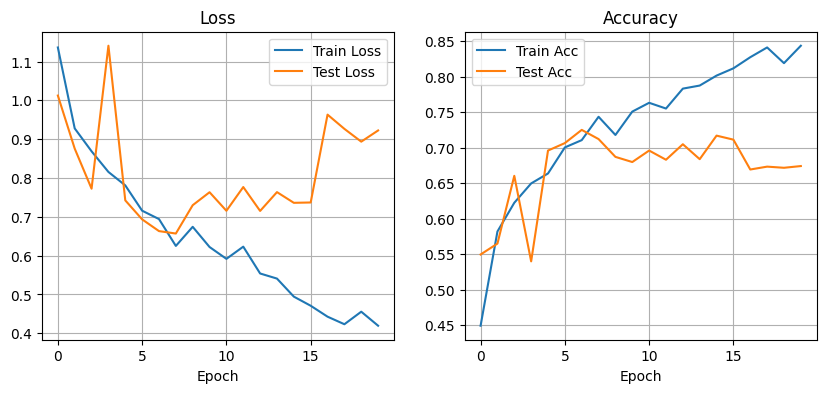

Pred: [1 1 2 0 3]
True: tensor([2, 1, 1, 0, 1])
Confusion Matrix:
 [[265  36  12  43]
 [ 45 168  55  35]
 [ 15  37 161  65]
 [ 23  13  24 240]]

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.74      0.75       356
           1       0.66      0.55      0.60       303
           2       0.64      0.58      0.61       278
           3       0.63      0.80      0.70       300

    accuracy                           0.67      1237
   macro avg       0.67      0.67      0.67      1237
weighted avg       0.68      0.67      0.67      1237


Accuracy: 0.6742





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (5932, 100)
y shape: (5932,)
env_ids shape: (5932,)


X_data shape: (5932, 1, 100)


X_train: torch.Size([4449, 1, 100])
X_test : torch.Size([1483, 1, 100])
y_train: torch.Size([4449])
y_test : torch.Size([1483])


Epoch [1/20] Train Loss: 0.7273, Train Acc: 0.7038 | Test Loss: 0.6099, Test Acc: 0.7363
Epoch [2/20] Train Loss:

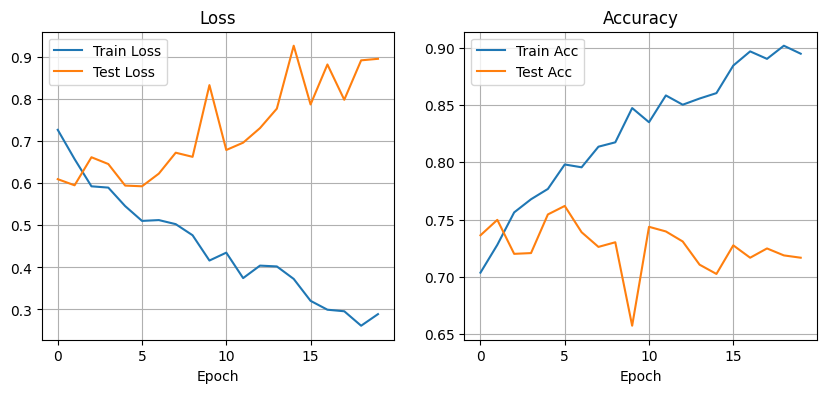

Pred: [2 2 2 0 3]
True: tensor([2, 2, 2, 0, 2])
Confusion Matrix:
 [[303  46  19  59]
 [ 35 273  41  14]
 [  8  40 247  38]
 [ 17  37  66 240]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.71      0.77       427
           1       0.69      0.75      0.72       363
           2       0.66      0.74      0.70       333
           3       0.68      0.67      0.68       360

    accuracy                           0.72      1483
   macro avg       0.72      0.72      0.72      1483
weighted avg       0.72      0.72      0.72      1483


Accuracy: 0.7168





--- WINDOW_SIZE=500, STRIDE=60 ---

X shape: (4812, 500)
y shape: (4812,)
env_ids shape: (4812,)


X_data shape: (4812, 1, 500)


X_train: torch.Size([3609, 1, 500])
X_test : torch.Size([1203, 1, 500])
y_train: torch.Size([3609])
y_test : torch.Size([1203])


Epoch [1/20] Train Loss: 0.4424, Train Acc: 0.8357 | Test Loss: 0.3177, Test Acc: 0.8753
Epoch [2/20] Train Loss:

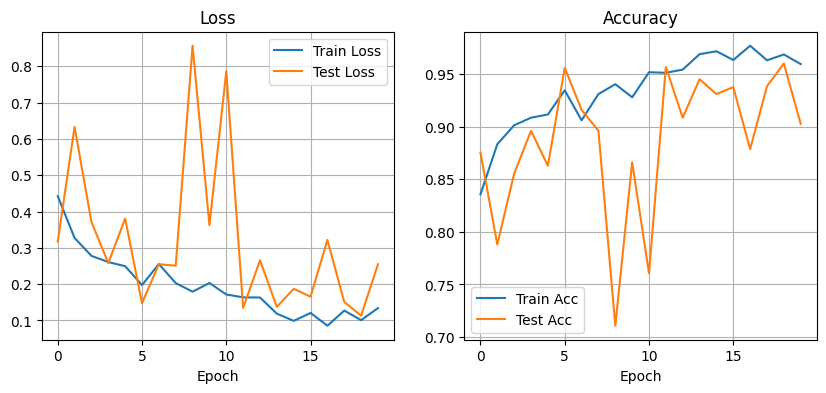

Pred: [3 3 0 2 2]
True: tensor([3, 3, 0, 2, 2])
Confusion Matrix:
 [[347   1   0   0]
 [ 45 236   0  14]
 [ 16   3 219  31]
 [  7   0   0 284]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91       348
           1       0.98      0.80      0.88       295
           2       1.00      0.81      0.90       269
           3       0.86      0.98      0.92       291

    accuracy                           0.90      1203
   macro avg       0.92      0.90      0.90      1203
weighted avg       0.92      0.90      0.90      1203


Accuracy: 0.9027





--- WINDOW_SIZE=500, STRIDE=50 ---

X shape: (5772, 500)
y shape: (5772,)
env_ids shape: (5772,)


X_data shape: (5772, 1, 500)


X_train: torch.Size([4329, 1, 500])
X_test : torch.Size([1443, 1, 500])
y_train: torch.Size([4329])
y_test : torch.Size([1443])


Epoch [1/20] Train Loss: 0.2138, Train Acc: 0.9226 | Test Loss: 0.5129, Test Acc: 0.8205
Epoch [2/20] Train Loss:

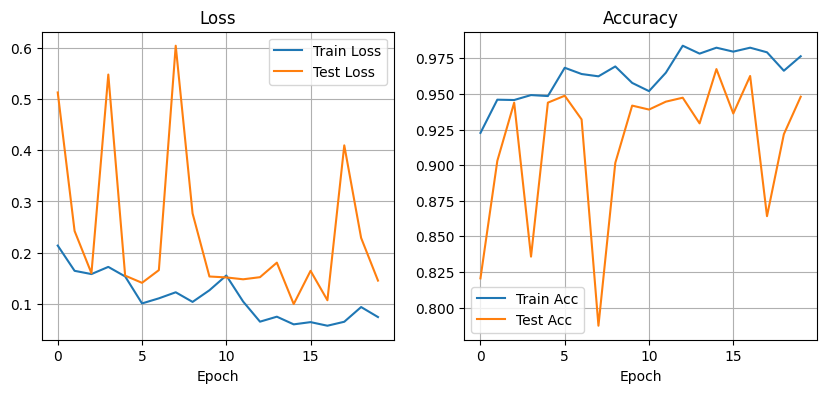

Pred: [3 0 0 3 1]
True: tensor([3, 0, 0, 3, 1])
Confusion Matrix:
 [[409   7   0   1]
 [ 15 314  15   9]
 [  1  10 306   6]
 [  1   0  10 339]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       417
           1       0.95      0.89      0.92       353
           2       0.92      0.95      0.94       323
           3       0.95      0.97      0.96       350

    accuracy                           0.95      1443
   macro avg       0.95      0.95      0.95      1443
weighted avg       0.95      0.95      0.95      1443


Accuracy: 0.9480





--- WINDOW_SIZE=1000, STRIDE=60 ---

X shape: (4646, 1000)
y shape: (4646,)
env_ids shape: (4646,)


X_data shape: (4646, 1, 1000)


X_train: torch.Size([3484, 1, 1000])
X_test : torch.Size([1162, 1, 1000])
y_train: torch.Size([3484])
y_test : torch.Size([1162])


Epoch [1/20] Train Loss: 0.0608, Train Acc: 0.9816 | Test Loss: 0.0191, Test Acc: 0.9957
Epoch [2/20] Train 

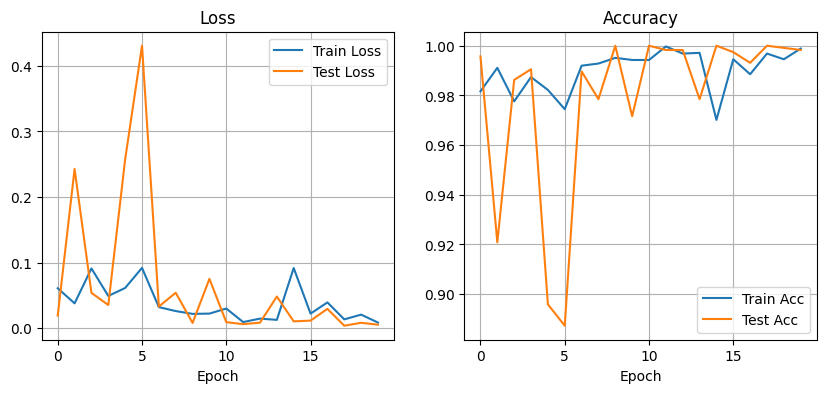

Pred: [3 0 1 3 1]
True: tensor([3, 0, 1, 3, 1])
Confusion Matrix:
 [[335   2   0   0]
 [  0 285   0   0]
 [  0   0 259   0]
 [  0   0   0 281]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       337
           1       0.99      1.00      1.00       285
           2       1.00      1.00      1.00       259
           3       1.00      1.00      1.00       281

    accuracy                           1.00      1162
   macro avg       1.00      1.00      1.00      1162
weighted avg       1.00      1.00      1.00      1162


Accuracy: 0.9983





--- WINDOW_SIZE=1000, STRIDE=50 ---

X shape: (5572, 1000)
y shape: (5572,)
env_ids shape: (5572,)


X_data shape: (5572, 1, 1000)


X_train: torch.Size([4179, 1, 1000])
X_test : torch.Size([1393, 1, 1000])
y_train: torch.Size([4179])
y_test : torch.Size([1393])


Epoch [1/20] Train Loss: 0.0445, Train Acc: 0.9856 | Test Loss: 0.1379, Test Acc: 0.9541
Epoch [2/20] Train 

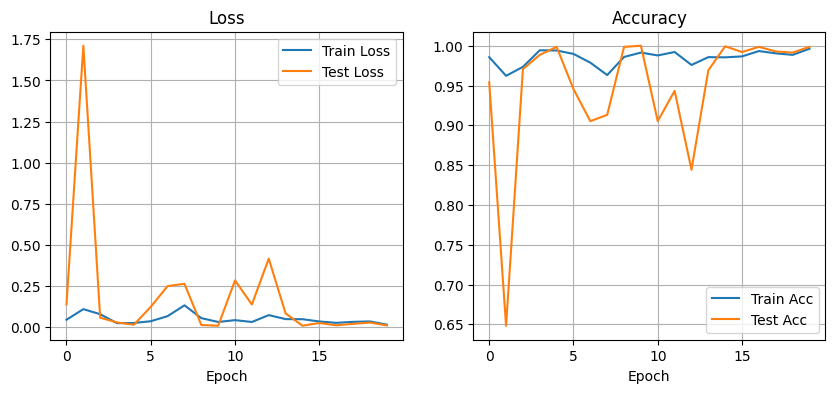

Pred: [1 0 0 0 3]
True: tensor([1, 0, 0, 0, 3])
Confusion Matrix:
 [[405   0   0   0]
 [  1 339   0   1]
 [  0   0 310   0]
 [  0   0   0 337]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       1.00      0.99      1.00       341
           2       1.00      1.00      1.00       310
           3       1.00      1.00      1.00       337

    accuracy                           1.00      1393
   macro avg       1.00      1.00      1.00      1393
weighted avg       1.00      1.00      1.00      1393


Accuracy: 0.9986






In [13]:
# ===========================
# version 1: random split
# ===========================

results_random = []

print("\n=== Version 1: random split ===\n")

for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, env_files=env_files, device_to_label=device_to_label)

            train_loader_r, test_loader_r, X_test_r_tensor, y_test_r_tensor = random_split(X_data, y)

            train_and_evaluate(model_r, train_loader_r, test_loader_r, criterion, optimizer, device, num_epochs)

            predict(model_r, X_test_r_tensor, y_test_r_tensor, device)
            
            acc = compute_confusion_matrix(model_r, test_loader_r, device)
            acc = round(acc, 4)
            
            results_random.append({
            "sequence length": window_size,
            "overlapping": 100 - stride,
            "acc": acc
            })

            print("\n\n")

In [14]:
# Version 2 model
# num_classes = len(np.unique(y))
model_e = ResNet1D(num_classes=4) # 4 classes for 4 nodes
print(model_e)

# === Model Summary ===
from torchinfo import summary

summary(
    model_e,
    input_size=(64, 1, 500)  # (batch, channel, length)
)

# =========================
# Step 3: training setup
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_e = model_e.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_e.parameters(), lr=0.001)

ResNet1D(
  (stem): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(2,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv1d(16, 16, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (bn2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
  )
  (layer2): Sequential(
    (0): ResidualBlock1D(
      (conv1): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,), bias=False)
      (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=T


=== Version 2: env-based split ===


--- WINDOW_SIZE=100, STRIDE=60 ---

X shape: (4946, 100)
y shape: (4946,)
env_ids shape: (4946,)


X_data shape: (4946, 1, 100)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([3941, 1, 100])
X_test : torch.Size([1005, 1, 100])
y_train: torch.Size([3941])
y_test : torch.Size([1005])


Epoch [1/20] Train Loss: 1.0851, Train Acc: 0.4864 | Test Loss: 3.4365, Test Acc: 0.1184
Epoch [2/20] Train Loss: 0.8638, Train Acc: 0.5976 | Test Loss: 2.9921, Test Acc: 0.2338
Epoch [3/20] Train Loss: 0.7730, Train Acc: 0.6567 | Test Loss: 2.5967, Test Acc: 0.2975
Epoch [4/20] Train Loss: 0.7223, Train Acc: 0.6765 | Test Loss: 2.4237, Test Acc: 0.2915
Epoch [5/20] Train Loss: 0.6578, Train Acc: 0.7084 | Test Loss: 3.1093, Test Acc: 0.1562
Epoch [6/20] Train Loss: 0.6245, Train Acc: 0.7232 | Test Loss: 2.8172, Test Acc: 0.2259
Epoch [7/20] Train Loss: 0.6376, Train Acc: 0.7255 | Test Loss: 2.5782, Test Acc: 0.3443
Epoch [8/20] Train Loss: 0.5889, Train 

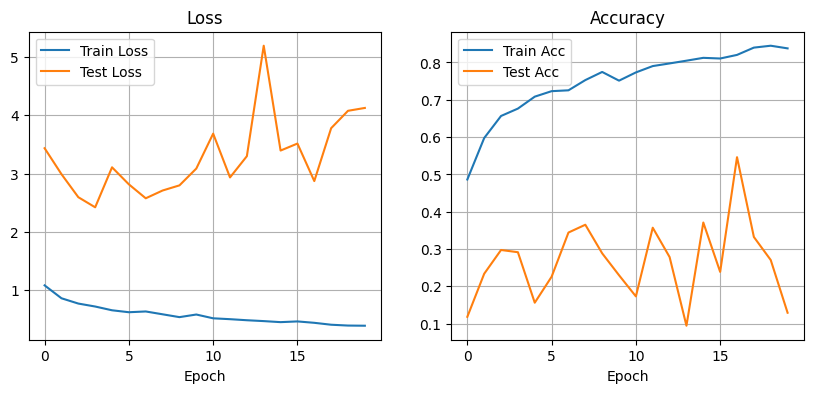

Pred: [3 3 3 2 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   2  46 215]
 [  0   0  24 273]
 [  0   0  94 141]
 [ 37 130   7  36]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       263
           1       0.00      0.00      0.00       297
           2       0.55      0.40      0.46       235
           3       0.05      0.17      0.08       210

    accuracy                           0.13      1005
   macro avg       0.15      0.14      0.14      1005
weighted avg       0.14      0.13      0.13      1005


Accuracy: 0.1294





--- WINDOW_SIZE=100, STRIDE=50 ---

X shape: (5932, 100)
y shape: (5932,)
env_ids shape: (5932,)


X_data shape: (5932, 1, 100)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([4726, 1, 100])
X_test : torch.Size([1206, 1, 100])
y_train: torch.Size([4726])
y_test : torch.Size([1206])


Epoch [1/20] Train Loss: 0.5401, Train Acc: 0.7666 | Test Loss: 5.1753, T

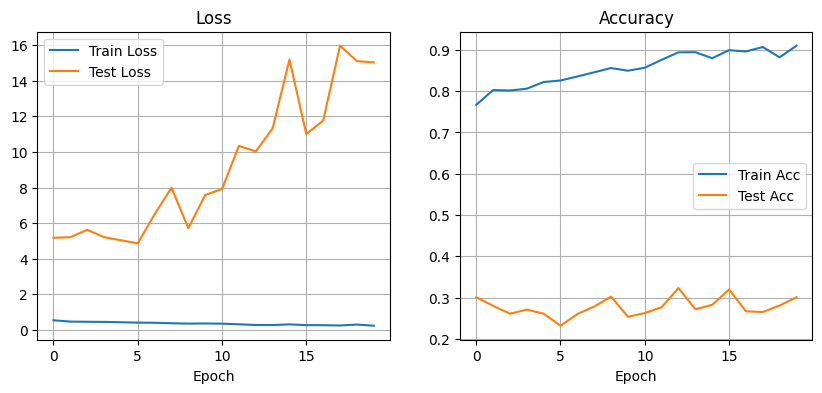

Pred: [1 1 3 1 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0 123   6 187]
 [  0   0 356   0]
 [  0   0 282   0]
 [ 36  25 110  81]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       316
           1       0.00      0.00      0.00       356
           2       0.37      1.00      0.54       282
           3       0.30      0.32      0.31       252

    accuracy                           0.30      1206
   macro avg       0.17      0.33      0.21      1206
weighted avg       0.15      0.30      0.19      1206


Accuracy: 0.3010





--- WINDOW_SIZE=500, STRIDE=60 ---

X shape: (4812, 500)
y shape: (4812,)
env_ids shape: (4812,)


X_data shape: (4812, 1, 500)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([3834, 1, 500])
X_test : torch.Size([978, 1, 500])
y_train: torch.Size([3834])
y_test : torch.Size([978])


Epoch [1/20] Train Loss: 0.2081, Train Acc: 0.9233 | Test Loss: 21.3345, Te

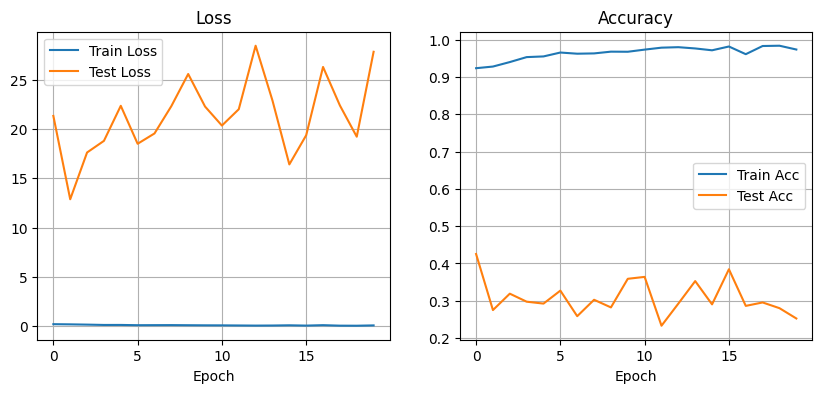

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   5   0 252]
 [  0   0 290   0]
 [  0   0 228   0]
 [  0   6 178  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       257
           1       0.00      0.00      0.00       290
           2       0.33      1.00      0.49       228
           3       0.07      0.09      0.08       203

    accuracy                           0.25       978
   macro avg       0.10      0.27      0.14       978
weighted avg       0.09      0.25      0.13       978


Accuracy: 0.2526





--- WINDOW_SIZE=500, STRIDE=50 ---



/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

X shape: (5772, 500)
y shape: (5772,)
env_ids shape: (5772,)


X_data shape: (5772, 1, 500)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([4598, 1, 500])
X_test : torch.Size([1174, 1, 500])
y_train: torch.Size([4598])
y_test : torch.Size([1174])


Epoch [1/20] Train Loss: 0.0931, Train Acc: 0.9652 | Test Loss: 21.4395, Test Acc: 0.2802
Epoch [2/20] Train Loss: 0.0690, Train Acc: 0.9791 | Test Loss: 27.9413, Test Acc: 0.3220
Epoch [3/20] Train Loss: 0.0772, Train Acc: 0.9732 | Test Loss: 26.1087, Test Acc: 0.2504
Epoch [4/20] Train Loss: 0.0667, Train Acc: 0.9774 | Test Loss: 21.8191, Test Acc: 0.2530
Epoch [5/20] Train Loss: 0.0427, Train Acc: 0.9874 | Test Loss: 25.3370, Test Acc: 0.2828
Epoch [6/20] Train Loss: 0.0481, Train Acc: 0.9837 | Test Loss: 23.5511, Test Acc: 0.2521
Epoch [7/20] Train Loss: 0.0727, Train Acc: 0.9743 | Test Loss: 23.5439, Test Acc: 0.3220
Epoch [8/20] Train Loss: 0.0454, Train Acc: 0.9854 | Test Loss: 29.6178, Test Acc: 0.2359
Epoch [9/20] Tra

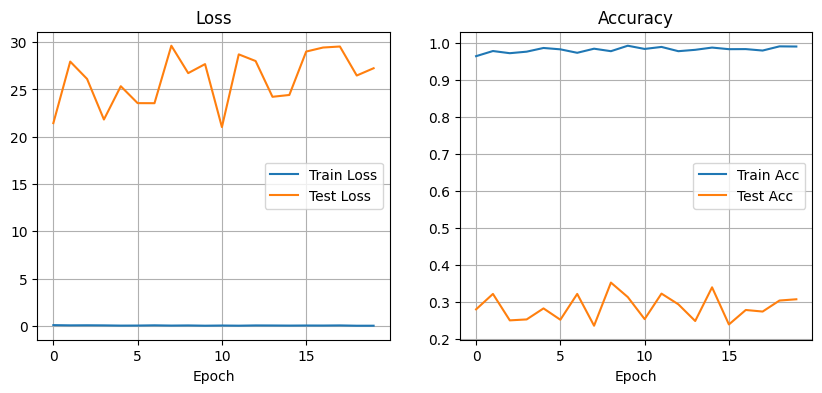

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0 111   8 189]
 [  0   0 348   0]
 [  0   0 274   0]
 [  1   0 156  87]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       308
           1       0.00      0.00      0.00       348
           2       0.35      1.00      0.52       274
           3       0.32      0.36      0.33       244

    accuracy                           0.31      1174
   macro avg       0.17      0.34      0.21      1174
weighted avg       0.15      0.31      0.19      1174


Accuracy: 0.3075





--- WINDOW_SIZE=1000, STRIDE=60 ---

X shape: (4646, 1000)
y shape: (4646,)
env_ids shape: (4646,)


X_data shape: (4646, 1, 1000)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([3701, 1, 1000])
X_test : torch.Size([945, 1, 1000])
y_train: torch.Size([3701])
y_test : torch.Size([945])


Epoch [1/20] Train Loss: 0.0075, Train Acc: 0.9997 | Test Loss: 31.514

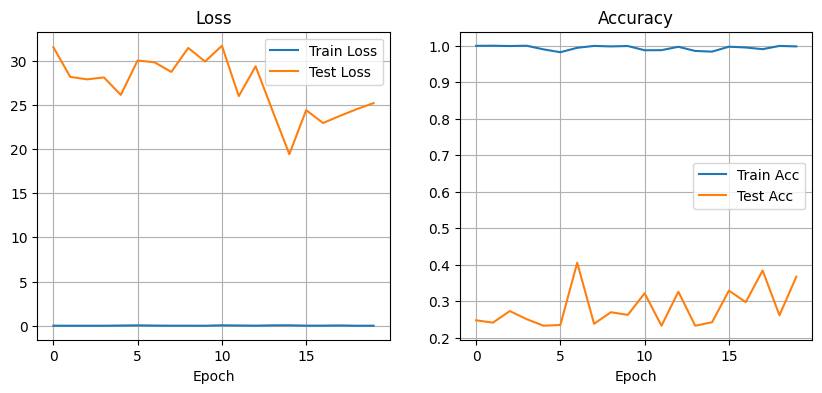

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0  62 186]
 [  0   0 282   0]
 [  0   0 220   0]
 [  0  28  40 127]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       248
           1       0.00      0.00      0.00       282
           2       0.36      1.00      0.53       220
           3       0.41      0.65      0.50       195

    accuracy                           0.37       945
   macro avg       0.19      0.41      0.26       945
weighted avg       0.17      0.37      0.23       945


Accuracy: 0.3672





--- WINDOW_SIZE=1000, STRIDE=50 ---



/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

X shape: (5572, 1000)
y shape: (5572,)
env_ids shape: (5572,)


X_data shape: (5572, 1, 1000)


Train envs: [0, 1, 2, 3]
Test env : 4


X_train: torch.Size([4438, 1, 1000])
X_test : torch.Size([1134, 1, 1000])
y_train: torch.Size([4438])
y_test : torch.Size([1134])


Epoch [1/20] Train Loss: 0.0164, Train Acc: 0.9948 | Test Loss: 28.1565, Test Acc: 0.2778
Epoch [2/20] Train Loss: 0.0184, Train Acc: 0.9937 | Test Loss: 25.8994, Test Acc: 0.2981
Epoch [3/20] Train Loss: 0.0403, Train Acc: 0.9860 | Test Loss: 23.4777, Test Acc: 0.2328
Epoch [4/20] Train Loss: 0.0327, Train Acc: 0.9912 | Test Loss: 28.4941, Test Acc: 0.2328
Epoch [5/20] Train Loss: 0.0436, Train Acc: 0.9849 | Test Loss: 32.6272, Test Acc: 0.3413
Epoch [6/20] Train Loss: 0.0188, Train Acc: 0.9948 | Test Loss: 30.4182, Test Acc: 0.2390
Epoch [7/20] Train Loss: 0.0127, Train Acc: 0.9971 | Test Loss: 31.6432, Test Acc: 0.3113
Epoch [8/20] Train Loss: 0.0437, Train Acc: 0.9845 | Test Loss: 25.6583, Test Acc: 0.3166
Epoch [9/20]

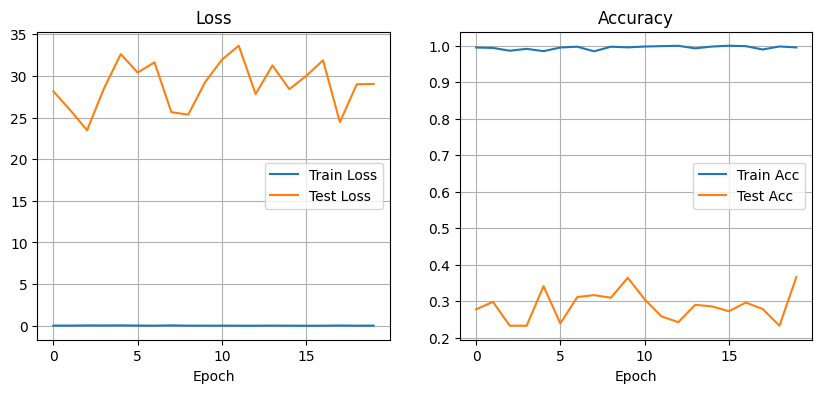

Pred: [3 3 3 3 3]
True: tensor([0, 0, 0, 0, 0])
Confusion Matrix:
 [[  0   0 141 157]
 [  0   0 338   0]
 [  0   0 264   0]
 [  0   1  82 151]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       298
           1       0.00      0.00      0.00       338
           2       0.32      1.00      0.48       264
           3       0.49      0.65      0.56       234

    accuracy                           0.37      1134
   macro avg       0.20      0.41      0.26      1134
weighted avg       0.18      0.37      0.23      1134


Accuracy: 0.3660






/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hzyc/iot-ml/ml/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [15]:
# ===========================
# version 2: env-based split
# ===========================
results_env = []

print("\n=== Version 2: env-based split ===\n")
for window_size in WINDOW_SIZE:
      for stride in STRIDE:
            print(f"\n--- WINDOW_SIZE={window_size}, STRIDE={stride} ---\n")
            
            X_data, y, env_ids = build_dataset(window_size, stride, env_files=env_files, device_to_label=device_to_label)

            train_loader_e, test_loader_e, X_test_e_tensor, y_test_e_tensor = env_based_split(X_data, y, env_ids)

            train_and_evaluate(model_e, train_loader_e, test_loader_e, criterion, optimizer, device, num_epochs)

            predict(model_e, X_test_e_tensor, y_test_e_tensor, device)

            acc = compute_confusion_matrix(model_e, test_loader_e, device)
            acc = round(acc, 4)

            results_env.append({
            "sequence length": window_size,
            "overlapping": 100 - stride,
            "acc": acc
            })
            print("\n\n")

In [16]:
df_results_ran = pd.DataFrame(results_random)
print("\n=== Random Split Accuracy Results ===\n")
print(f"{df_results_ran.to_string(index=False)}\n")

df_results_env = pd.DataFrame(results_env)
print("\n=== Env-based Split Accuracy Results ===\n")
print(f"{df_results_env.to_string(index=False)}\n")


=== Random Split Accuracy Results ===

 sequence length  overlapping    acc
             100           40 0.6742
             100           50 0.7168
             500           40 0.9027
             500           50 0.9480
            1000           40 0.9983
            1000           50 0.9986


=== Env-based Split Accuracy Results ===

 sequence length  overlapping    acc
             100           40 0.1294
             100           50 0.3010
             500           40 0.2526
             500           50 0.3075
            1000           40 0.3672
            1000           50 0.3660



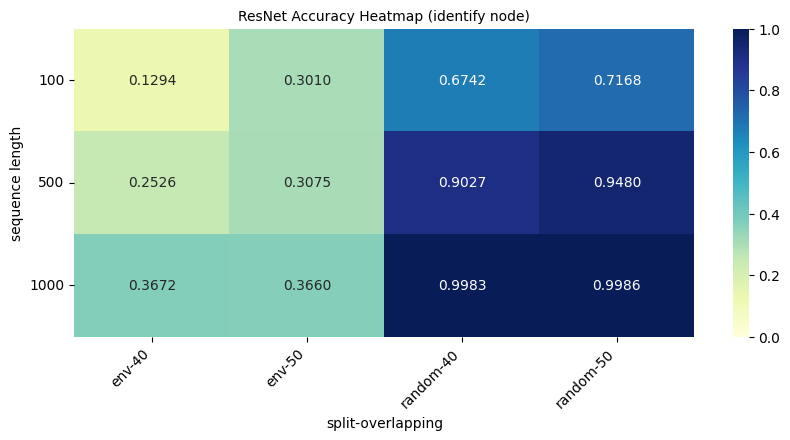

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

df_results_ran["split"] = "random"
df_results_env["split"] = "env"

df_all = pd.concat([df_results_ran, df_results_env])

pivot_all = df_all.pivot_table(
    index="sequence length",
    columns=["split", "overlapping"],
    values="acc"
)

plt.figure(figsize=(10,4))
sns.heatmap(
    pivot_all, 
    annot=True, 
    fmt=".4f",
    cmap="YlGnBu",
    vmin=0.0, 
    vmax=1.0
)

plt.title("ResNet Accuracy Heatmap (identify node)", fontsize=10)


plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.savefig("heatmap/heatmap_resnet_identify_node.png", bbox_inches='tight', dpi=300)